In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import random_split
from torch.nn.parameter import Parameter
from sklearn.cluster import KMeans

In [ ]:
MODEL_NAME = "DCEC_2"
BATCH_SIZE = 128
LEARNING_RATE = 0.001
NUM_EPOCHS = 30
NUM_CLUSTERS = 10
ALPHA = 1
GAMMA = 0.1

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [4]:
transform = transforms.ToTensor()

mnist_data = datasets.MNIST(root="./data", train=True, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(dataset=mnist_data, batch_size=BATCH_SIZE, shuffle=False)

In [5]:
dataiter = iter(train_loader)
images, labels = next(dataiter)
print(torch.min(images), torch.max(images))

tensor(0.) tensor(1.)


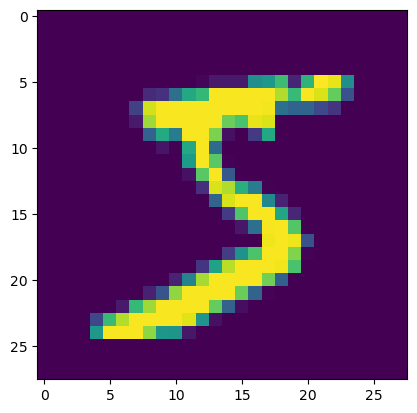

In [6]:
image = images[0]
image = image.permute(1, 2, 0)
plt.imshow(image)

In [7]:
class Reshape(nn.Module):
    def __init__(self, *shape):
        super().__init__()
        self.shape = shape  # this should be the target shape without the batch dim (e.g. (32, 7, 7))

    def forward(self, x):
        return x.view(x.size(0), *self.shape)

class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=4, stride=2, padding=1), # 32 x 14 x 14
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1), # 64 x 7 x 7
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1), # 128 x 3 x 3
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(128*3*3, 10), # Latent Rep dim. 10
        )

        self.decoder = nn.Sequential(
            nn.Linear(10, 128*3*3),
            nn.ReLU(),
            Reshape(128, 3, 3),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1, output_padding=1), # 64 x 7 x 7
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),  # 32 x 14 x 14
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1, kernel_size=4, stride=2, padding=1),  # 1 x 28 x 28
            nn.Sigmoid()
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return encoded, decoded

class ClusteringLayer(nn.Module):
    def __init__(self, n_clusters=NUM_CLUSTERS, cluster_centers=None, alpha=ALPHA):
        super(ClusteringLayer, self).__init__()
        self.n_clusters = n_clusters
        self.alpha = alpha
        self.cluster_centers = Parameter(cluster_centers) # Cluster centres are updated during training
    
    def forward(self, x):
        norm_squared = torch.sum((x.unsqueeze(1) - self.cluster_centers)**2, 2)
        numerator = 1.0 / (1.0 + (norm_squared / self.alpha))
        power = float(self.alpha + 1) / 2
        numerator = numerator**power
        t_dist = (numerator.t() / torch.sum(numerator, 1)).t()  # soft assignment using t-distribution
        return t_dist
    
class DEC(nn.Module):
    def __init__(self, n_clusters=NUM_CLUSTERS, autoencoder=None, cluster_centres=None, alpha=ALPHA):
        super(DEC, self).__init__()
        self.n_clusters = n_clusters
        self.alpha = alpha
        self.cluster_centres = cluster_centres
        self.autoencoder = autoencoder
        self.clusteringlayer = ClusteringLayer(self.n_clusters, self.cluster_centres, self.alpha)
    
    def target_distribution(self, q_):
        weight = (q_ ** 2) / torch.sum(q_, 0)
        return (weight.t() / torch.sum(weight, 1)).t()
    
    def forward(self, x):
        encoded = self.autoencoder.encoder(x)
        soft_ass = self.clusteringlayer(encoded)
        decoded = self.autoencoder.decoder(encoded)
        return soft_ass, decoded


In [8]:
def save_checkpoint(model, optimizer, epoch, filename="checkpoint.pth"):
    
    checkpoint = {
        "epoch": epoch,
        "model_state": model.state_dict(),
        "optim_state": optimizer.state_dict()
    }
    
    torch.save(checkpoint, filename)

In [9]:
# Load pretrained Autoencoder and initialise cluster centres

model_AE = Autoencoder().to(device)
model_AE.load_state_dict(torch.load(r"C:\Users\ea197\Projects\Literature-Review-ML\AE_MNIST\AE_2_weights.pth", map_location=device))

all_latents = []

model_AE.eval()
with torch.no_grad():
    for img, _ in train_loader:
        img = img.to(device)
        
        encoded, _ = model_AE(img)   # encoded shape: (batch_size, 10)
        
        all_latents.append(encoded.cpu())

all_latents = torch.cat(all_latents, dim=0)  # shape: (num_train_samples, 10)
print("Encoded feature shape:", all_latents.shape)

kmeans = KMeans(n_clusters=NUM_CLUSTERS, n_init=20) # runs k-means with 20 restarts and selects the best solution (lowest inertia)
kmeans.fit(all_latents.numpy())
cluster_centers = torch.tensor(kmeans.cluster_centers_, dtype=torch.float32).to(device)

print("Cluster centers initialised:", cluster_centers.shape)

C:\Users\ea197\AppData\Local\Temp\ipykernel_27028\3449148909.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_AE.load_state_dict(torch.load(r"C:\Users\ea197\Project

Encoded feature shape: torch.Size([60000, 10])
Cluster centers initialised: torch.Size([10, 10])


In [10]:
model_DEC = DEC(n_clusters=NUM_CLUSTERS, autoencoder=model_AE, cluster_centres=cluster_centers, alpha=ALPHA).to(device)
criterion_MSE = nn.MSELoss()
criterion_KL = nn.KLDivLoss(reduction="batchmean")
optimizer = torch.optim.Adam(model_DEC.parameters(), lr=LEARNING_RATE)

In [11]:
# Training loop

loss_values = []
num_epoch = []

prev_p = None
prev_labels = None
tol = 0.001  # 0.1% change threshold
early_stopped = False

for epoch in range(NUM_EPOCHS):
    running_total_loss = 0.0
    batch_start = 0

    model_DEC.train()
    for (img, _) in train_loader:

        img = img.to(device)
        batch_size = img.size(0)
        batch_end = batch_start + batch_size

        # Forward pass
        q, decoded = model_DEC(img)

        if epoch == 0:
            # First epoch: compute p batch-wise
            with torch.no_grad():
                p_batch = model_DEC.target_distribution(q).detach()
        else:
            # Later epochs: use previous epoch's p (detached)
            p_batch = prev_p[batch_start:batch_end].to(device)
        
        clustering_loss = criterion_KL(q.log(), p_batch)
        recon_loss = criterion_MSE(decoded, img)
        total_loss = recon_loss + GAMMA * clustering_loss

        optimizer.zero_grad()
        total_loss.backward()
        optimizer.step()

        running_total_loss += total_loss.item()
        batch_start = batch_end

    epoch_loss = running_total_loss / len(train_loader)
    loss_values.append(epoch_loss)
    num_epoch.append(epoch)

    # Generate new q for all data (to compute new p and check assignments)
    model_DEC.eval()
    all_q = []
    with torch.no_grad():
        for img, _ in train_loader:
            img = img.to(device)
            q_batch, _ = model_DEC(img)
            all_q.append(q_batch.cpu())

    all_q = torch.cat(all_q, dim=0) # Stack batches vertically (i.e. combine rows) to get shape (N, num_clusters)
    _, new_labels = torch.max(all_q, dim=1) # Computes the arg-max across clusters. For each row (each sample), it finds the cluster index with the highest probability.

    # Update target distribution p for next epoch
    prev_p = model_DEC.target_distribution(all_q.to(device)).detach()

    # Check stopping criterion (0.1%)
    if prev_labels is not None:
        changed = torch.sum(prev_labels != new_labels).item()  # Counts how many data points changed their cluster assignment between the previous and current epoch
        change_ratio = changed / len(new_labels)

        print(f"Epoch:{epoch+1}, Train Loss:{epoch_loss:.4f}, Cluster assignment change ratio: {change_ratio*100:.6f}%")

        if change_ratio < tol:
            print("Early stopping: cluster assignment change < 0.1%")
            save_checkpoint(model_DEC, optimizer, epoch, filename=f"{MODEL_NAME}_best.pth")
            early_stopped = True
            break
    else:
        print(f"Epoch:{epoch+1}, Train Loss:{epoch_loss:.4f}")

    prev_labels = new_labels.clone()

if not early_stopped:
    save_checkpoint(model_DEC, optimizer, epoch, filename=f"{MODEL_NAME}_final.pth")

print("Training Complete!")

Epoch:1, Train Loss:0.0389
Epoch:2, Train Loss:0.0313, Cluster assignment change ratio: 0.931667%
Epoch:3, Train Loss:0.0290, Cluster assignment change ratio: 0.738333%
Epoch:4, Train Loss:0.0275, Cluster assignment change ratio: 0.606667%
Epoch:5, Train Loss:0.0265, Cluster assignment change ratio: 0.510000%
Epoch:6, Train Loss:0.0257, Cluster assignment change ratio: 0.425000%
Epoch:7, Train Loss:0.0249, Cluster assignment change ratio: 0.340000%
Epoch:8, Train Loss:0.0243, Cluster assignment change ratio: 0.295000%
Epoch:9, Train Loss:0.0237, Cluster assignment change ratio: 0.280000%
Epoch:10, Train Loss:0.0233, Cluster assignment change ratio: 0.275000%
Epoch:11, Train Loss:0.0229, Cluster assignment change ratio: 0.218333%
Epoch:12, Train Loss:0.0224, Cluster assignment change ratio: 0.225000%
Epoch:13, Train Loss:0.0220, Cluster assignment change ratio: 0.190000%
Epoch:14, Train Loss:0.0217, Cluster assignment change ratio: 0.165000%
Epoch:15, Train Loss:0.0214, Cluster assignme

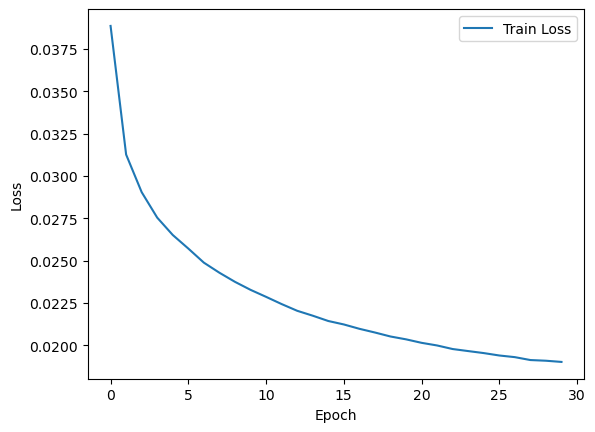

In [12]:
plt.plot(num_epoch, loss_values, label="Train Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()